In [1]:
import pandas as pd
import seaborn as sns

## 학습순서
1. 데이터로드       load_dataset
2. 기본구조확인     info, dtype, columns, unique
3. 조회             head, tail, loc, iloc
4. 필터링           조건검색         
5. 결측치 처리      fillna, dropna
6. 정렬             sort_values
7. 그룹화           groupby         
8. 집계             mean, sum, values_count
9. 새로운 컬럼추가  
10. 통계             corr, describe
11. 시각화           plot
12. 실습문제

## 1 데이터 로드 

In [ ]:
# 타이타닉 데이터 로드
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2 기본구조확인
survived	pclass	 sex	age	sibsp	  parch	 fare	   embarked	   class	   who	  adult_male	deck	embark_town	alive	 alone
생존여부  객실등급 성별 나이 형제수 자녀수 운임요금 승선항구코드 객실클스 승객구분 성인남성 선실간판 승선도시  생존상태 혼자탑승여부

In [ ]:
#컬럼 확인
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


도메인: 해당 컬럼이 가질 수 있는 값의 범위

도메인 분석은 매우 중요
- 데이터 이해
- 이상치 발견
- 코드값 분석
- DB 설계
- 머신러닝 전처리

In [ ]:
# 특정 컬럼의 도메인 확인
df['who'].unique()

<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str

In [58]:
# 모든 컬럼의 도메인 확인
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

survived
[0 1]

pclass
[3 1 2]

sex
<StringArray>
['male', 'female']
Length: 2, dtype: str

age
[22.         38.         26.         35.         29.69911765 54.
  2.         27.         14.          4.         58.         20.
 39.         55.         31.         34.         15.         28.
  8.         19.         40.         66.         42.         21.
 18.          3.          7.         49.         29.         65.
 28.5         5.         11.         45.         17.         32.
 16.         25.          0.83       30.         33.         23.
 24.         46.         59.         71.         37.         47.
 14.5        70.5        32.5        12.          9.         36.5
 51.         55.5        40.5        44.          1.         61.
 56.         50.         36.         45.5        20.5        62.
 41.         52.         63.         23.5         0.92       43.
 60.         10.         64.         13.         48.          0.75
 53.         57.         80.         70.         24.5   

In [57]:
df['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [55]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [56]:
df['pclass'].unique()

array([3, 1, 2])

In [ ]:
#데이터 타입 확인
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [9]:
# 전체정보
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [10]:
# 기초 통계
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3 데이터 조회

In [11]:
# 상위 5개
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
# 하위 5개
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [13]:
# 특정 컬럼
df['age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [14]:
# 여러 컬럼
df[['sex','age','fare']]

,sex,age,fare
0,male,22.0,7.2500
1,female,38.0,71.2833
2,female,26.0,7.9250
3,female,35.0,53.1000
4,male,35.0,8.0500
...,...,...,...
886,male,27.0,13.0000
887,female,19.0,30.0000
888,female,NaN,23.4500
889,male,26.0,30.0000


## 4 조건 검색

In [ ]:
# 여성 승객
df[df['sex'] == 'female']

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [22]:
# 생존자만
df[df['survived']==1]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [ ]:
# 조건 여러 개
df[(df['survived']==1) & (df['sex']=='female')]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,1,2,female,28.0,1,0,24.0000,C,Second,woman,False,NaN,Cherbourg,yes,False
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False


## 5 결측치 확인
결측치(NaN)란 값이 비어 있음
결측치 처리 방법은 제거하거나 다른 값으로 채움
- dropna() <- 결측치가 있는 행/열 삭제. 기본적으로 행삭제이며 열삭제 시에는 df.dropna(axis=1)
- fillna() <- 다른값으로 채우기

In [ ]:
# 결측치 개수 확인
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
# 결측치 제거
df.dropna()   # drop not avaliable. NA = Not Abailable  비파괴 함수(non-destructive)

# 파괴함수. 원본자체변경
# df.dropon(inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [32]:
df['age'].mean()

np.float64(29.69911764705882)

In [ ]:
# 결측치 채우기
# 평균(mean): 일반숫자, 중앙값(mediun): 이상치 많을 때, 최빈값(mode):범주형, 0:특별한 의미 있을 떄

df['age']=df['age'].fillna(df['age'].mean())  # 비파쾨함수라서 원본 컬럼에 다시 저장해야 함

## 6. 정렬

In [ ]:
# 나이순 정렬
df.sort_values('age')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
803,1,3,male,0.42,0,1,8.5167,C,Third,child,False,NaN,Cherbourg,yes,False
755,1,2,male,0.67,1,1,14.5000,S,Second,child,False,NaN,Southampton,yes,False
469,1,3,female,0.75,2,1,19.2583,C,Third,child,False,NaN,Cherbourg,yes,False
644,1,3,female,0.75,2,1,19.2583,C,Third,child,False,NaN,Cherbourg,yes,False
78,1,2,male,0.83,0,2,29.0000,S,Second,child,False,NaN,Southampton,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,0,3,male,70.50,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
493,0,1,male,71.00,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
96,0,1,male,71.00,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
851,0,3,male,74.00,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True


In [36]:
# 요금 높은 순 정렬(descending)
df.sort_values('fare', ascending=False)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
679,1,1,male,36.000000,0,1,512.3292,C,First,man,True,B,Cherbourg,yes,False
258,1,1,female,35.000000,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True
737,1,1,male,35.000000,0,0,512.3292,C,First,man,True,B,Cherbourg,yes,True
88,1,1,female,23.000000,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False
438,0,1,male,64.000000,1,4,263.0000,S,First,man,True,C,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,0,1,male,39.000000,0,0,0.0000,S,First,man,True,A,Southampton,no,True
815,0,1,male,29.699118,0,0,0.0000,S,First,man,True,B,Southampton,no,True
466,0,2,male,29.699118,0,0,0.0000,S,Second,man,True,NaN,Southampton,no,True
481,0,2,male,29.699118,0,0,0.0000,S,Second,man,True,NaN,Southampton,no,True


## 7 그룹화

In [ ]:
#성별 평균 나이
df.groupby('sex')['age'].mean()

sex
female    27.915709
male      30.726645
Name: age, dtype: float64

In [37]:
# 객실 등급별 평균 요금
df.groupby('pclass')['fare'].mean()

pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64

In [39]:
# 성별 생존률
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

# 8 value_counts()

In [40]:
## 객실 등급별 인원수
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [42]:
# 객실 등급별 인원수
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

## 9 새로운 컬럼 생성

In [43]:
# 가족 수
df['family_size'] = df['sibsp'] + df['parch']

In [44]:
# 성인여부
df['adult'] = df['age'] >= 20

## 10. 상관 계수
- 변수 관계 변수. 어떤 변수끼리 관련 있는지 확인
- feature selection : 예측에 중요한 컬럼 찾기
- 다중 공선성 확인 : 비슷한 컬럼 제거

In [ ]:
# 상관계수 행렬(Correlation Matrix) <- 숫자형 컬럼들끼리의 상관계수를 계산한 표. 행 컬럼 vs 열 컬럼의 관계 강도
df.corr(numeric_only=True)
# pclass 와 fare : 음의 상관관계. 객실 등급 숫자가 높을수록 요금 낮음
# survived 와 fare : 약한 양의 상관관계. 요금 높은 승객이 상대적으로 생존률 높음

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,family_size,adult
survived,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,-0.557080,-0.203367,0.016639,-0.095582
pclass,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,0.094035,0.135207,0.065997,-0.126098
age,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,0.253236,0.179775,-0.248512,0.647646
sibsp,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,-0.253586,-0.584471,0.890712,-0.255485
parch,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,-0.349943,-0.583398,0.783111,-0.260339
fare,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,-0.182024,-0.271832,0.217138,0.003916
adult_male,-0.557080,0.094035,0.253236,-0.253586,-0.349943,-0.182024,1.000000,0.404744,-0.348143,0.294980
alone,-0.203367,0.135207,0.179775,-0.584471,-0.583398,-0.271832,0.404744,1.000000,-0.690922,0.265389
family_size,0.016639,0.065997,-0.248512,0.890712,0.783111,0.217138,-0.348143,-0.690922,1.000000,-0.304676
adult,-0.095582,-0.126098,0.647646,-0.255485,-0.260339,0.003916,0.294980,0.265389,-0.304676,1.000000


In [46]:
# 생존과 관련높은 컬럼
df.corr(numeric_only=True)['survived']

survived       1.000000
pclass        -0.338481
age           -0.069809
sibsp         -0.035322
parch          0.081629
fare           0.257307
adult_male    -0.557080
alone         -0.203367
family_size    0.016639
adult         -0.095582
Name: survived, dtype: float64

## 11 시각화

<Axes: xlabel='survived'>

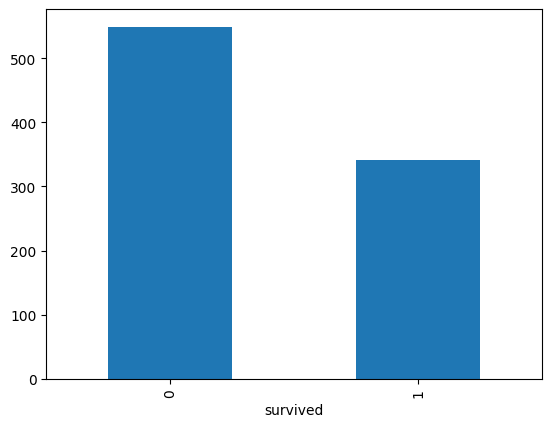

In [ ]:
import matplotlib.pyplot as plt
# 생존자 수
df['survived'].value_counts().plot(kind='bar') 

<Axes: xlabel='sex'>

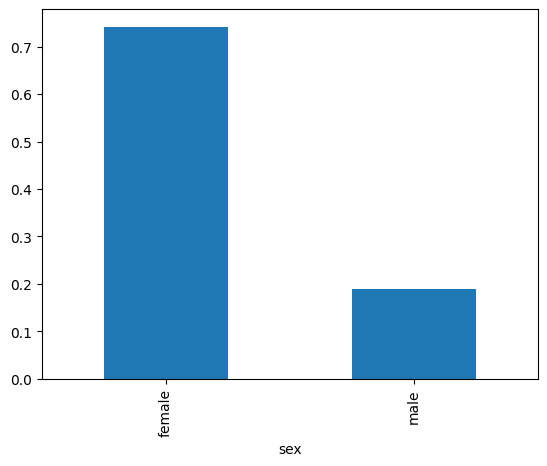

In [ ]:
# 성별 생존율
df.groupby('sex')['survived'].mean().plot(kind='bar')

<Axes: >

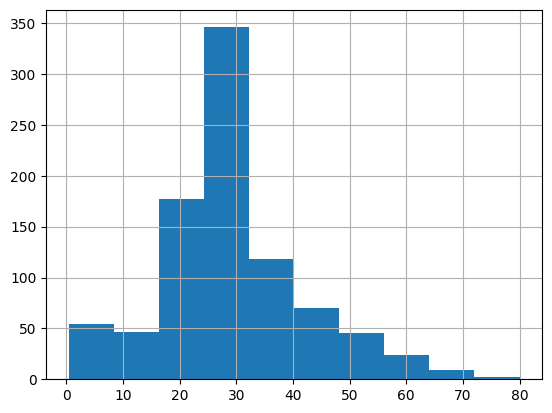

In [52]:
# 나이분포
df['age'].hist()

## 12 실습문제
1. 여성생존자 수 구하기
2. 가장 비싼 요금 승객 찾기
3. 나이가 가장 많은 승객
4. 객실 등급별 생존률